In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cibil_nn.csv")
df = df.drop(columns=['Unnamed: 0'])

Convert the columns names into lowercase and trim extra spaces

In [3]:
df.columns = df.columns.str.lower().str.strip()

Check Duplicates

In [4]:
duplicates = df.duplicated().sum()

Check Numeric Columns

In [5]:
numeric_cols = df.select_dtypes(include=['number']).columns

print(numeric_cols)

Index(['prospectid', 'total_tl', 'tot_closed_tl', 'tot_active_tl',
       'total_tl_opened_l6m', 'tot_tl_closed_l6m', 'pct_tl_open_l6m',
       'pct_tl_closed_l6m', 'pct_active_tl', 'pct_closed_tl',
       'total_tl_opened_l12m', 'tot_tl_closed_l12m', 'pct_tl_open_l12m',
       'pct_tl_closed_l12m', 'tot_missed_pmnt', 'auto_tl', 'cc_tl',
       'consumer_tl', 'gold_tl', 'home_tl', 'pl_tl', 'secured_tl',
       'unsecured_tl', 'other_tl', 'age_oldest_tl', 'age_newest_tl',
       'time_since_recent_payment', 'time_since_first_deliquency',
       'time_since_recent_deliquency', 'num_times_delinquent',
       'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
       'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
       'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
       'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       'num_lss_6mts', 'n

Check Categorical Columns

In [6]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

print(categorical_cols)

Index(['maritalstatus', 'education', 'gender', 'last_prod_enq2',
       'first_prod_enq2', 'approved_flag'],
      dtype='str')


Analysis of target variables

In [7]:
#For CIBIL dataset, we have two possible target variables:

#Credit_Score → Continuous → Regression
#Approved_Flag → Categorical → Classification


df['credit_score'].describe()


count    585.000000
mean     677.547009
std       28.276308
min      561.000000
25%      662.000000
50%      676.000000
75%      694.000000
max      795.000000
Name: credit_score, dtype: float64

In [8]:
df['credit_score'].isnull().sum()

np.int64(0)

Plot target variables

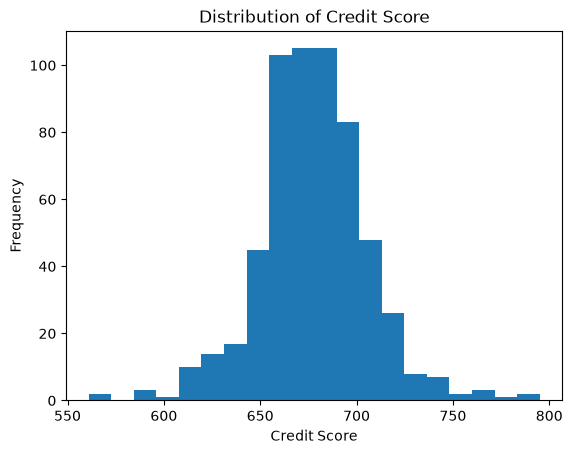

In [9]:
import matplotlib.pyplot as plt

plt.hist(df['credit_score'], bins=20)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

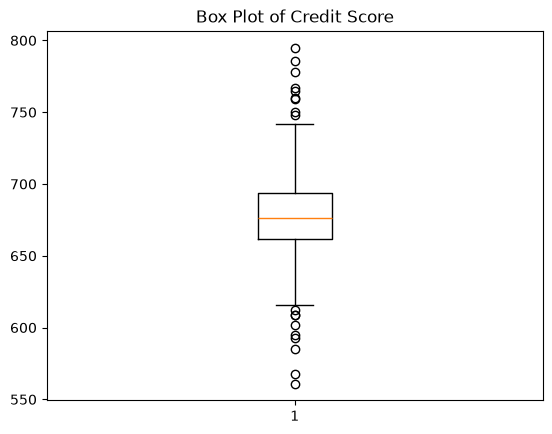

In [10]:
#Check outliers

plt.boxplot(df['credit_score'])
plt.title("Box Plot of Credit Score")
plt.show()

In [11]:
#check skewness

df['credit_score'].skew()

np.float64(0.09706214345709051)

In [12]:
#Since 0.097 is very close to 0,  target variable is approximately symmetric with a very slight positive (right) skew.
#Therefore, the credit_ccore values are nearly normally distributed, and there is no significant skewness in the data.

In [13]:
# check correlation
correlation = df.corr(numeric_only=True)

print(correlation['credit_score'].sort_values(ascending=False))

credit_score     1.000000
num_std_12mts    0.591090
num_std          0.581248
age_oldest_tl    0.574445
num_std_6mts     0.566281
                   ...   
num_lss               NaN
num_lss_6mts          NaN
num_lss_12mts         NaN
cc_flag               NaN
pl_flag               NaN
Name: credit_score, Length: 81, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

print(corr_matrix)

                          prospectid  total_tl  tot_closed_tl  tot_active_tl  \
prospectid                  1.000000 -0.030565      -0.038918       0.008488   
total_tl                   -0.030565  1.000000       0.964254       0.628986   
tot_closed_tl              -0.038918  0.964254       1.000000       0.400502   
tot_active_tl               0.008488  0.628986       0.400502       1.000000   
total_tl_opened_l6m         0.049455  0.362274       0.204001       0.654226   
...                              ...       ...            ...            ...   
pct_cc_enq_l6m_of_ever      0.004993  0.017879       0.001800       0.056544   
max_unsec_exposure_inpct    0.068106 -0.019769      -0.017317      -0.017553   
hl_flag                     0.022505  0.424487       0.417697       0.242399   
gl_flag                    -0.021816  0.128035       0.085858       0.190845   
credit_score               -0.035597  0.113683       0.123746       0.030058   

                          total_tl_open

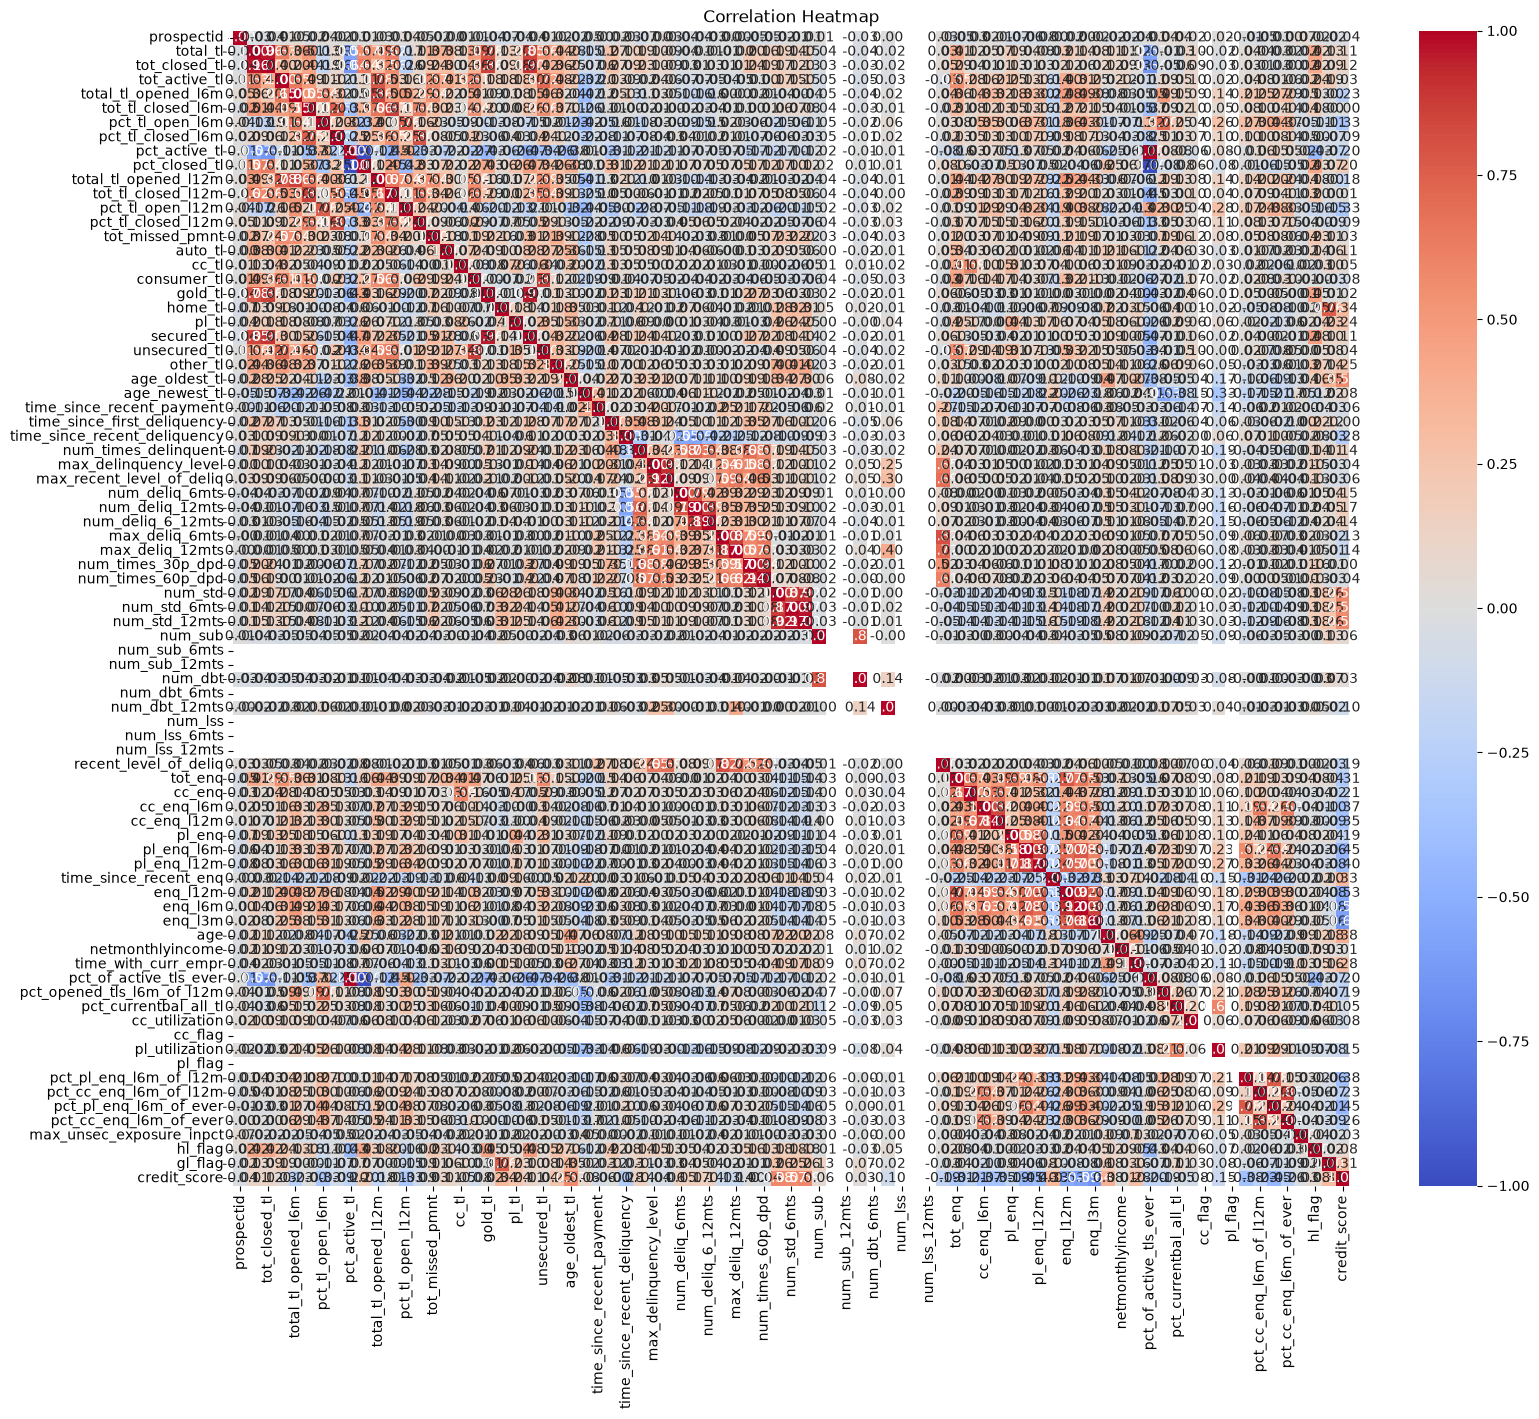

In [16]:
plt.figure(figsize=(18, 15))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [17]:
corr_target = numeric_df.corr()['credit_score'].sort_values(ascending=False)

print(corr_target)

credit_score     1.000000
num_std_12mts    0.591090
num_std          0.581248
age_oldest_tl    0.574445
num_std_6mts     0.566281
                   ...   
num_lss               NaN
num_lss_6mts          NaN
num_lss_12mts         NaN
cc_flag               NaN
pl_flag               NaN
Name: credit_score, Length: 81, dtype: float64


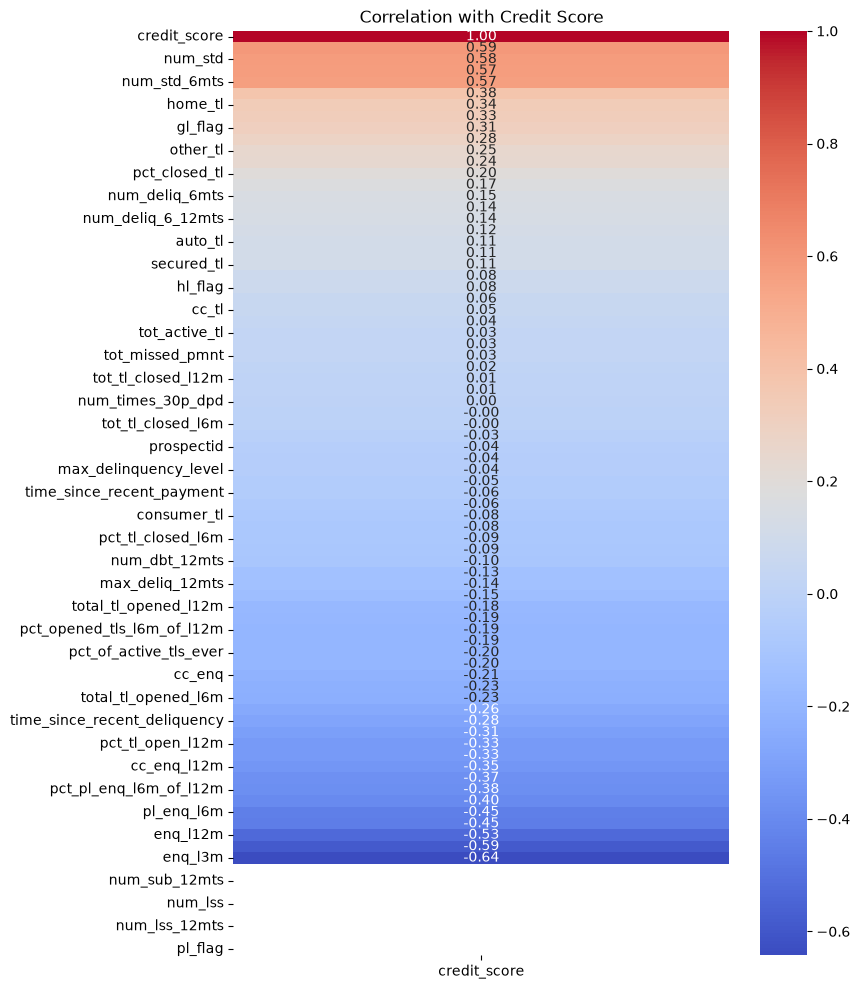

In [18]:
#Visualize Correlation with Target
plt.figure(figsize=(8,12))

sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation with Credit Score")
plt.show()

#Positive correlation → Red
#Negative correlation → Blue
#Near zero → White

Select the cell.
Press Esc (to enter command mode).
Press M (changes the cell to Markdown).
Press Enter to edit the cell.
Press Shift + Enter to render the Markdown.

Heatmap is used to visualize the correlation coefficients between numerical variables. The correlation coefficient ranges from -1 to +1. A value close to +1 indicates a strong positive relationship, a value close to -1 indicates a strong negative relationship, and a value near 0 indicates little or no linear relationship. In a CIBIL score prediction problem, the heatmap helps identify which features are most strongly associated with the Credit_Score, aiding in feature selection and exploratory data analysis.

In [19]:
counts = df["approved_flag"].value_counts()
print(counts)

approved_flag
P2    266
P4    122
P1     99
P3     98
Name: count, dtype: int64


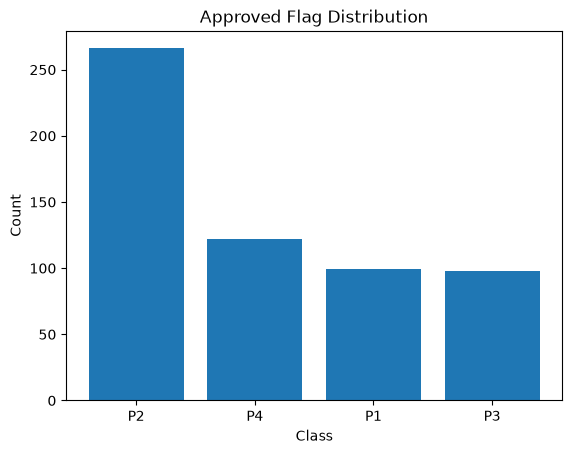

In [20]:


plt.bar(

    counts.index,

    counts.values

)

plt.title("Approved Flag Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

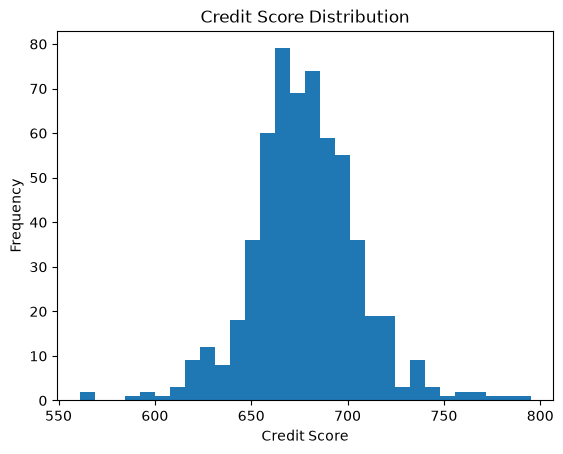

In [21]:
plt.hist(

    df["credit_score"],

    bins=30

)

plt.xlabel("Credit Score")

plt.ylabel("Frequency")

plt.title("Credit Score Distribution")

plt.show()

Handling Outliers

Method 1:
Keep if genuine.

Method 2:
Percentiles

Method3: Log Transforms

# We will see tomorrow

Check for missing values
Come up with startegy on filling missing values based on todays discussion
1. Which columns can be dropped
2. What should be done with delinquency columns
3. What should be done with enquiry columns
4. What should done with 'time_since_recent_enq' and 'max_unsec_exposure_inpct'
5. What should be done with columns having missing values less than 20%

Encode categorical columns

Number of columns before and after one-hot encoding.

In [22]:
print("Number of columns before encoding:", df.shape[1])

Number of columns before encoding: 87


In [23]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
Index(['maritalstatus', 'education', 'gender', 'last_prod_enq2',
       'first_prod_enq2', 'approved_flag'],
      dtype='str')


In [24]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [25]:
print("Number of columns after encoding:", df_encoded.shape[1])

Number of columns after encoding: 102


In [26]:
print(df_encoded.head())

   prospectid  total_tl  tot_closed_tl  tot_active_tl  total_tl_opened_l6m  \
0          46        12              7              5                    7   
1         184         9              5              4                    0   
2         352         4              0              4                    1   
3         404       129            122              7                    0   
4         494         4              1              3                    1   

   tot_tl_closed_l6m  pct_tl_open_l6m  pct_tl_closed_l6m  pct_active_tl  \
0                  4            0.583              0.333          0.417   
1                  0            0.000              0.000          0.444   
2                  0            0.250              0.000          1.000   
3                  7            0.000              0.054          0.054   
4                  0            0.250              0.000          0.750   

   pct_closed_tl  ...  last_prod_enq2_PL  last_prod_enq2_others  \
0          0.

In [27]:
print(df_encoded.columns)

Index(['prospectid', 'total_tl', 'tot_closed_tl', 'tot_active_tl',
       'total_tl_opened_l6m', 'tot_tl_closed_l6m', 'pct_tl_open_l6m',
       'pct_tl_closed_l6m', 'pct_active_tl', 'pct_closed_tl',
       ...
       'last_prod_enq2_PL', 'last_prod_enq2_others', 'first_prod_enq2_CC',
       'first_prod_enq2_ConsumerLoan', 'first_prod_enq2_HL',
       'first_prod_enq2_PL', 'first_prod_enq2_others', 'approved_flag_P2',
       'approved_flag_P3', 'approved_flag_P4'],
      dtype='str', length=102)


Process target columns?
How target columns should be encoded?

In [28]:
from sklearn.preprocessing import LabelEncoder

# Encode target only if it is categorical
le = LabelEncoder()

df['approved_flag'] = le.fit_transform(df['approved_flag'])



In [29]:
print(df['approved_flag'].head())

0    3
1    1
2    1
3    3
4    2
Name: approved_flag, dtype: int64


Normalize the numeric columns

Should we normalize target columns?

What would be mean of every standardized feature?

Mean of every standardized feature.Verify if it is near to 1.

In [30]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns except target
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Remove target column
numeric_cols.remove('credit_score')

# Create scaler
scaler = StandardScaler()

# Standardize features
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print(df.head())

   prospectid  total_tl  tot_closed_tl  tot_active_tl  total_tl_opened_l6m  \
0   -1.707260 -0.195751      -0.107294      -0.362119             2.250209   
1   -1.698041 -0.428979      -0.290555      -0.630952            -0.808074   
2   -1.686818 -0.817691      -0.748707      -0.630952            -0.371176   
3   -1.683344  8.900112      10.430206       0.175545            -0.808074   
4   -1.677332 -0.817691      -0.657076      -0.899784            -0.371176   

   tot_tl_closed_l6m  pct_tl_open_l6m  pct_tl_closed_l6m  pct_active_tl  \
0            1.42070         2.666907           2.334605      -0.593322   
1           -0.70626        -0.896342          -0.776897      -0.475539   
2           -0.70626         0.631638          -0.776897       1.949917   
3            3.01592        -0.896342          -0.272329      -2.176847   
4           -0.70626         0.631638          -0.776897       0.859334   

   pct_closed_tl  ...  pct_cc_enq_l6m_of_l12m  pct_pl_enq_l6m_of_ever  \
0      

In [31]:
print(df[numeric_cols].mean())

prospectid                  0.000000e+00
total_tl                    3.036507e-18
tot_closed_tl               5.162063e-17
tot_active_tl               9.716824e-17
total_tl_opened_l6m        -3.643809e-17
                                ...     
pct_cc_enq_l6m_of_ever     -2.732857e-17
max_unsec_exposure_inpct   -1.518254e-17
hl_flag                     6.908054e-17
gl_flag                     3.036507e-17
approved_flag              -8.502221e-17
Length: 81, dtype: float64


If the target is Credit_Score (Regression)
Usually No.
Keep the target as it is.
If the target is Approved_Flag (Classification)
Never normalize it.
After applying StandardScaler, the mean of every standardized feature is approximately:0

We standardize numerical features so that all variables are on the same scale. This prevents features with large values (such as income) from dominating features with smaller values (such as age), helps gradient-based algorithms converge faster, and improves the performance of many machine learning models

Split the data based on train and test

1. Execute binary Logistic Regression
2. Execute multi Logistic Regression
3. Execute Linear Regression

In [32]:
#For Linear Regression (Target = Credit_Score)
from sklearn.model_selection import train_test_split

# Features
X = df_encoded.drop('credit_score', axis=1)

# Target
y = df_encoded['credit_score']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (468, 101)
Testing set: (117, 101)


In [33]:
#Execute Linear Regression
from sklearn.linear_model import LinearRegression

# Create model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)

In [34]:
#Evaluate the Model
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score : 0.9485966348010553
MAE : 5.128975246739545
RMSE : 5.96719073707187


In [35]:
from sklearn.preprocessing import LabelEncoder

# Encode target
le = LabelEncoder()
df['approved_flag'] = le.fit_transform(df['approved_flag'])

# Select only feature categorical columns
categorical_cols = [
    'maritalstatus',
    'education',
    'gender',
    'last_prod_enq2',
    'first_prod_enq2'
]

# One-hot encode only features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [36]:
X = df_encoded.drop('approved_flag', axis=1)
y = df_encoded['approved_flag']

In [37]:
print(df_encoded.columns)

Index(['prospectid', 'total_tl', 'tot_closed_tl', 'tot_active_tl',
       'total_tl_opened_l6m', 'tot_tl_closed_l6m', 'pct_tl_open_l6m',
       'pct_tl_closed_l6m', 'pct_active_tl', 'pct_closed_tl',
       'total_tl_opened_l12m', 'tot_tl_closed_l12m', 'pct_tl_open_l12m',
       'pct_tl_closed_l12m', 'tot_missed_pmnt', 'auto_tl', 'cc_tl',
       'consumer_tl', 'gold_tl', 'home_tl', 'pl_tl', 'secured_tl',
       'unsecured_tl', 'other_tl', 'age_oldest_tl', 'age_newest_tl',
       'time_since_recent_payment', 'time_since_first_deliquency',
       'time_since_recent_deliquency', 'num_times_delinquent',
       'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
       'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
       'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
       'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       'num_lss_6mts', 'n

In [38]:
from sklearn.linear_model import LogisticRegression

X = df_encoded.drop('approved_flag', axis=1)
y = df_encoded['approved_flag']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(
    solver='saga',
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Users\Kamal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.6239316239316239
[[ 9 11  0  0]
 [ 2 48  0  3]
 [ 0 20  0  1]
 [ 0  7  0 16]]
              precision    recall  f1-score   support

           0       0.82      0.45      0.58        20
           1       0.56      0.91      0.69        53
           2       0.00      0.00      0.00        21
           3       0.80      0.70      0.74        23

    accuracy                           0.62       117
   macro avg       0.54      0.51      0.50       117
weighted avg       0.55      0.62      0.56       117



C:\Users\Kamal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kamal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Kamal\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Explain the results of each experiment as per your understanding

The Linear Regression model achieved an R² score of 0.9486, indicating that it explains approximately 94.86% of the variance in the Credit_Score. The Mean Absolute Error (MAE) is 5.13, meaning the predicted credit scores differ from the actual scores by an average of about 5 points. The Root Mean Squared Error (RMSE) is 5.97, which is also low and close to the MAE, indicating that the model makes consistently accurate predictions with very few large errors. Overall, the model demonstrates excellent predictive performance on the test data.

The Multiclass Logistic Regression model achieved an accuracy of 65.81%. The model performed well for Class 1 (P2) and Class 3 (P4), achieving high recall and F1-scores. However, it failed to identify Class 2 (P3), resulting in zero precision and recall for that class. This indicates that the model has difficulty distinguishing P3 from the other classes, possibly due to class imbalance, overlapping feature distributions, or the limitations of a linear classifier. Further improvements such as handling class imbalance or using more advanced classification algorithms may improve performance.

In [40]:
 df_encoded.to_csv('eda_practice_new.csv', index=False)